## Data Understanding and Cleaning


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv')
df.head()

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer                       9134 non-null   object 
 1   State                          9134 non-null   object 
 2   Customer Lifetime Value        9134 non-null   float64
 3   Response                       9134 non-null   object 
 4   Coverage                       9134 non-null   object 
 5   Education                      9134 non-null   object 
 6   Effective To Date              9134 non-null   object 
 7   EmploymentStatus               9134 non-null   object 
 8   Gender                         9134 non-null   object 
 9   Income                         9134 non-null   int64  
 10  Location Code                  9134 non-null   object 
 11  Marital Status                 9134 non-null   object 
 12  Monthly Premium Auto           9134 non-null   i

In [4]:
df.shape

(9134, 24)

In [5]:
df.isna().sum()

Customer                         0
State                            0
Customer Lifetime Value          0
Response                         0
Coverage                         0
Education                        0
Effective To Date                0
EmploymentStatus                 0
Gender                           0
Income                           0
Location Code                    0
Marital Status                   0
Monthly Premium Auto             0
Months Since Last Claim          0
Months Since Policy Inception    0
Number of Open Complaints        0
Number of Policies               0
Policy Type                      0
Policy                           0
Renew Offer Type                 0
Sales Channel                    0
Total Claim Amount               0
Vehicle Class                    0
Vehicle Size                     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

### Identify unique values


In [7]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()}")

Customer: 9134
State: 5
Response: 2
Coverage: 3
Education: 5
Effective To Date: 59
EmploymentStatus: 5
Gender: 2
Location Code: 3
Marital Status: 3
Policy Type: 3
Policy: 9
Renew Offer Type: 4
Sales Channel: 4
Vehicle Class: 6
Vehicle Size: 3


In [8]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols

Index(['Customer Lifetime Value', 'Income', 'Monthly Premium Auto',
       'Months Since Last Claim', 'Months Since Policy Inception',
       'Number of Open Complaints', 'Number of Policies',
       'Total Claim Amount'],
      dtype='object')

### Parsing 'Effective To Date'


In [9]:
# convert to datetime
df['Effective To Date'] = pd.to_datetime(df['Effective To Date'])
    
# initialize date range for analysis
min_date = df['Effective To Date'].min()
max_date = df['Effective To Date'].max()

C:\Users\slim 3\AppData\Local\Temp\ipykernel_3400\3444972663.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Effective To Date'] = pd.to_datetime(df['Effective To Date'])


In [10]:
print(f"Date range: {min_date.date()} to {max_date.date()}")

Date range: 2011-01-01 to 2011-02-28


Only around half a month (1(1/2)) range.


## EDA


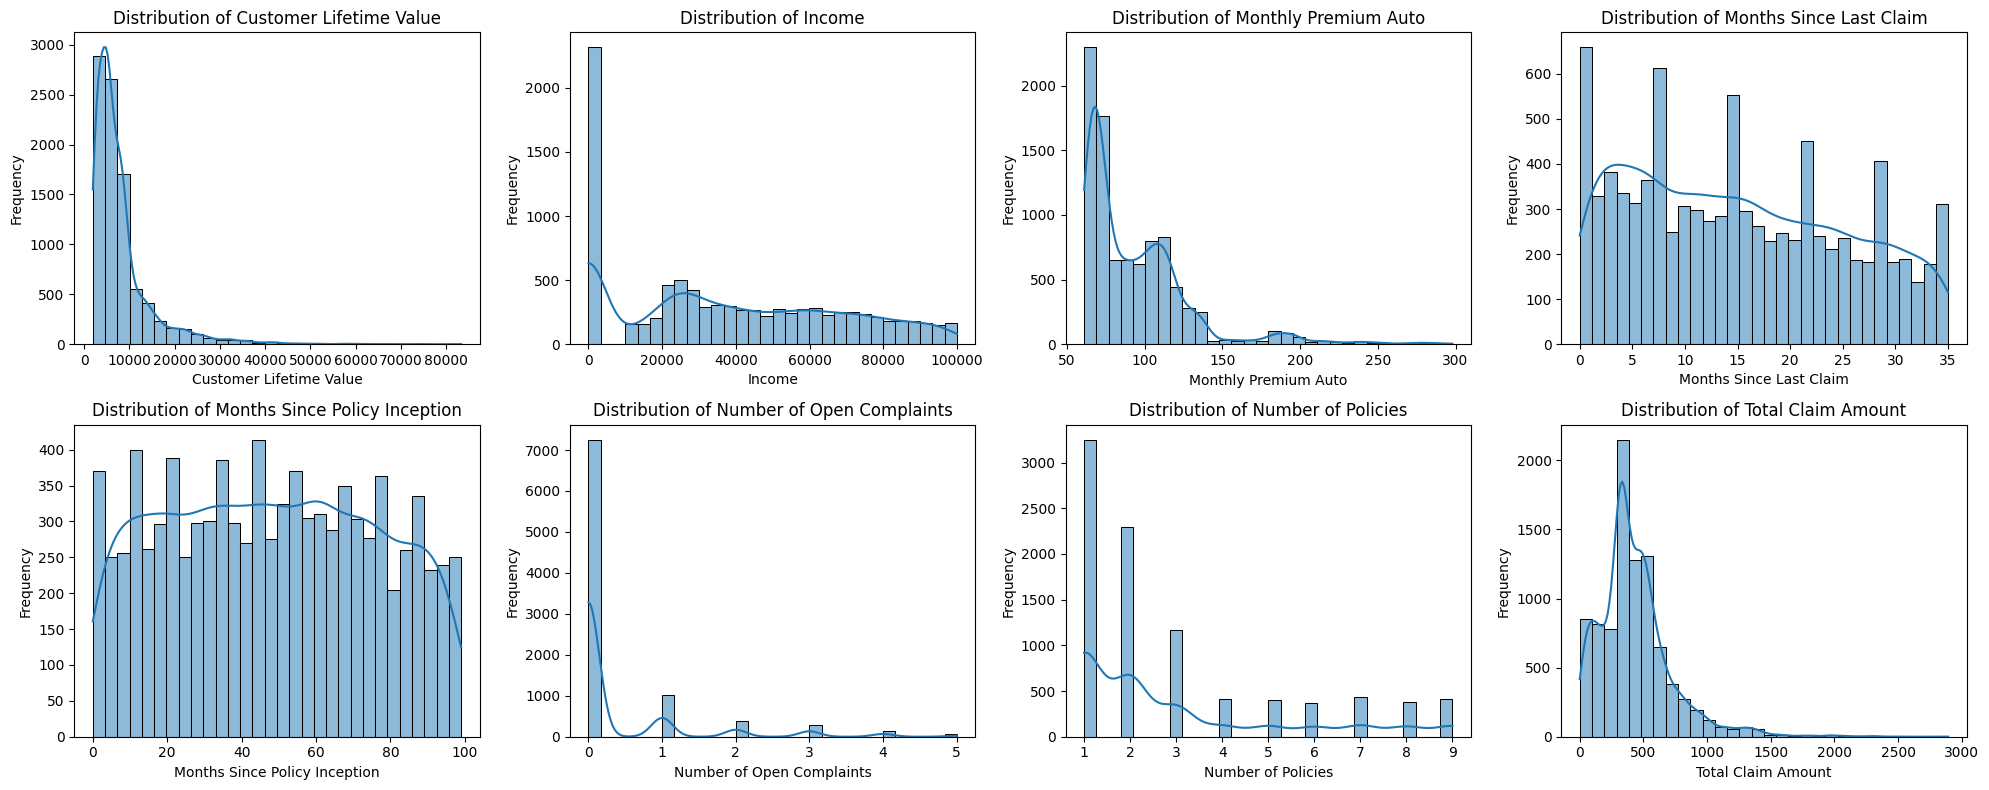

In [11]:
num_plots = len(numerical_cols)

n_cols = 4
n_rows = math.ceil(num_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Interpretation:

- CLV (Customer Lifetime Value) is heavily right skewed. To handle the skewness, transforming it with log1p can help reduce the skewness.
- There are many poeple with 0 income.


### Transforming CLV with log1p


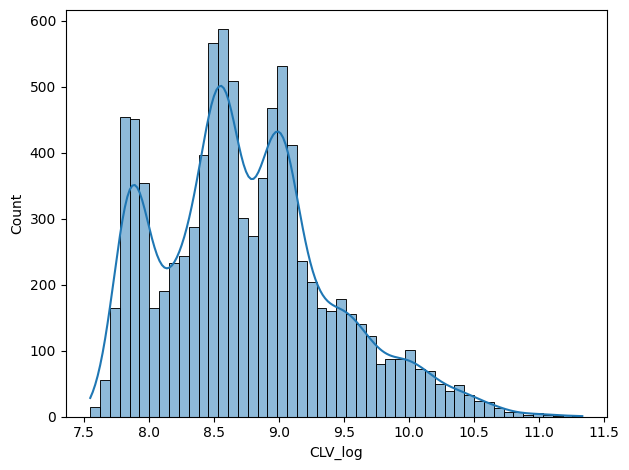

In [12]:
df['CLV_log'] = np.log1p(df['Customer Lifetime Value'])

sns.histplot(df['CLV_log'], bins=50, kde=True)
plt.tight_layout()
plt.show()

## Analyzing Income = 0


In [13]:
df['Zero_Income'] = (df['Income'] == 0).astype(int)

zero_income_count = df['Zero_Income'].sum()
zero_pct = (zero_income_count / len(df)) * 100
print(f"Total of 0 income: {zero_income_count} ({zero_pct:.2f}%)")

Total of 0 income: 2317 (25.37%)


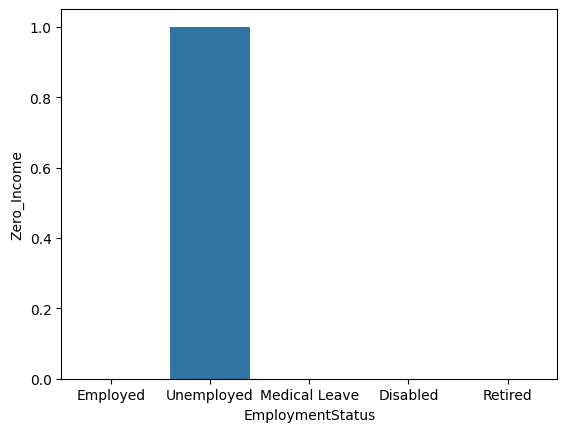

In [14]:
sns.barplot(x='EmploymentStatus', y='Zero_Income', data=df)
plt.show()

People with Income = 0 are most likely unemployed and not because of missing data (it can be seen from the chart).


## Analyzing CLV


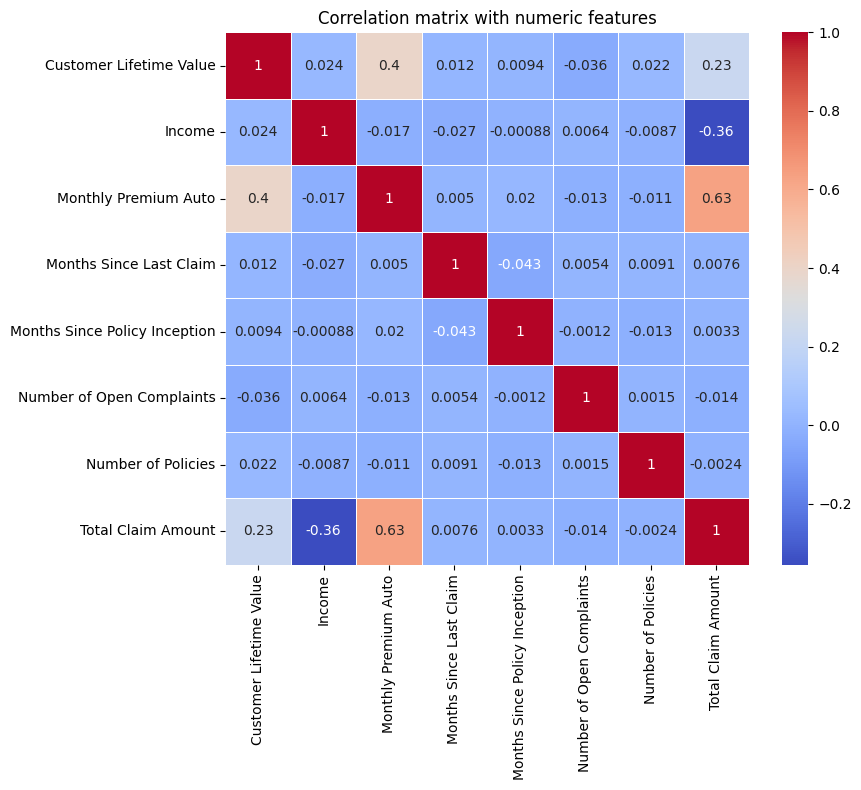

In [15]:
plt.figure(figsize=(9, 8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation matrix with numeric features")
plt.tight_layout()
plt.show()

CLV positively correlates most with 'Monthly Premium Auto' (0.4), where other numeric columns have weak correlation. Therefore, most of the signal for CLV will come from categorical columns and not raw numerical columns.


In [16]:
print("Top correlations with CLV:")
print(corr['Customer Lifetime Value'].drop('Customer Lifetime Value').sort_values(key=abs, ascending=False))

Top correlations with CLV:
Monthly Premium Auto             0.396262
Total Claim Amount               0.226451
Number of Open Complaints       -0.036343
Income                           0.024366
Number of Policies               0.021955
Months Since Last Claim          0.011517
Months Since Policy Inception    0.009418
Name: Customer Lifetime Value, dtype: float64


Choosing top 3 of the total drivers to be analyzed with CLV.


### Comparing CLV vs other numeric drivers


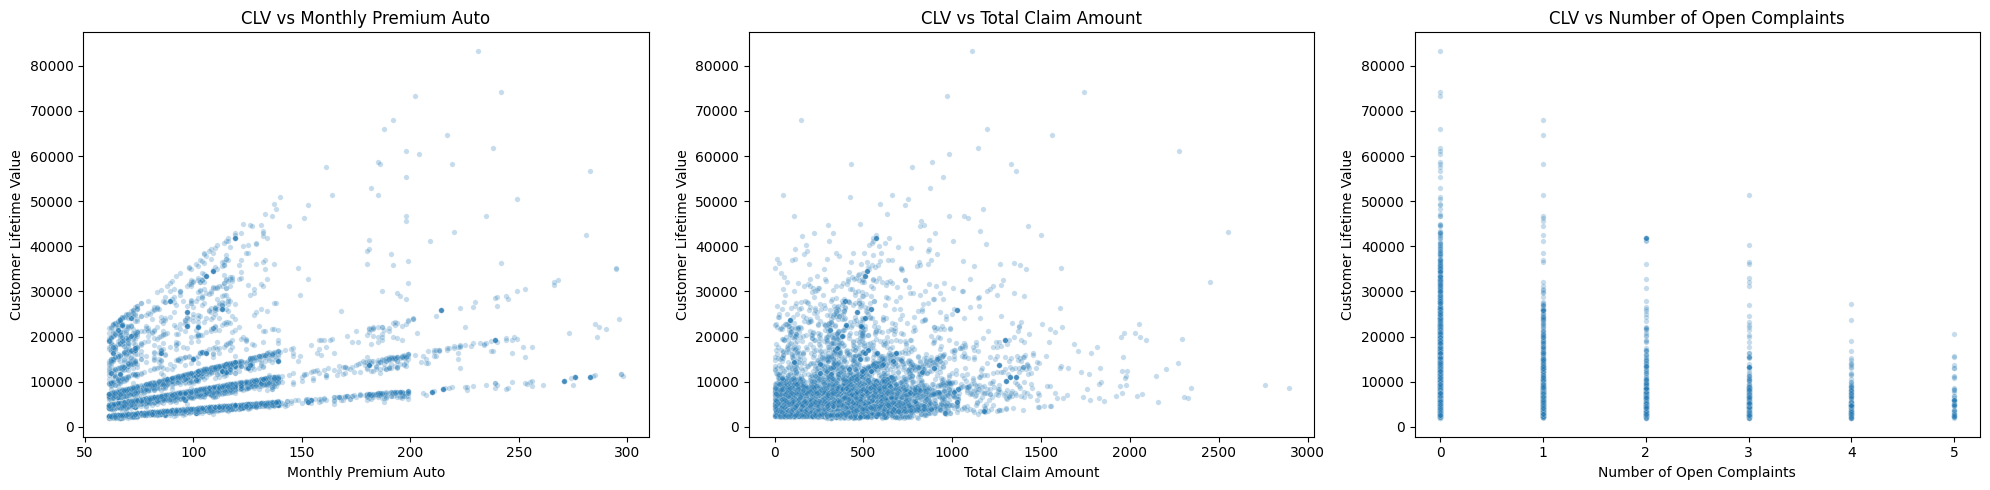

In [17]:
drivers = ["Monthly Premium Auto", "Total Claim Amount", "Number of Open Complaints"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes = axes.flatten()
for i, col in enumerate(drivers):
    sns.scatterplot(data=df, x=col, y='Customer Lifetime Value', alpha=0.25, s=15, ax=axes[i])
    axes[i].set_title(f"CLV vs {col}")

plt.tight_layout()
plt.show()

### CLV vs Monthly Premium Auto

- There exist a positive relationship.
- Customers with higher premiums tend to have higher CLV, eventhough it looks widely spread with some outliers.

### CLV vs Total Claim Amount

- Relationship seems weak.
- High CLV customers are found across different claim amounts, which could mean that claim amount alone doesn't strongly predict CLV.

### CLV vs Number of Open Complaints

- There is a negative relationship.
- Customers with fewer complaints tend to have a wider range of higher CLV values, while customers with more complaints have lower CLV.


## Feature Engineering


### Additional features


In [18]:
# Identify customers who file many claims despite having few policies
df['Claims_per_Policy'] = df['Total Claim Amount'] / df['Number of Policies']

# Identify affordability of insurance based on income and premium
# Handles Income = 0 by defaulting the ratio to 0 to avoid division by zero errors
df['Premium_to_Income_Ratio'] = np.where(df['Income'] > 0, df['Monthly Premium Auto'] / df['Income'], 0)

# Standardizes open complaints by the number of policies held
df['Complaints_per_Policy'] = df['Number of Open Complaints'] / df['Number of Policies']

### Train test split and encode categorical features


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import category_encoders as ce

In [20]:
X = df.drop(columns=['CLV_log', 'Customer', 'Effective To Date', 'Customer Lifetime Value'])
y = df['CLV_log']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"{col}: {X[col].nunique()}")

State: 5
Response: 2
Coverage: 3
Education: 5
EmploymentStatus: 5
Gender: 2
Location Code: 3
Marital Status: 3
Policy Type: 3
Policy: 9
Renew Offer Type: 4
Sales Channel: 4
Vehicle Class: 6
Vehicle Size: 3


In [22]:
for col in cat_cols:
    print(f"{col}: {X[col].unique().tolist()}")

State: ['Washington', 'Arizona', 'Nevada', 'California', 'Oregon']
Response: ['No', 'Yes']
Coverage: ['Basic', 'Extended', 'Premium']
Education: ['Bachelor', 'College', 'Master', 'High School or Below', 'Doctor']
EmploymentStatus: ['Employed', 'Unemployed', 'Medical Leave', 'Disabled', 'Retired']
Gender: ['F', 'M']
Location Code: ['Suburban', 'Rural', 'Urban']
Marital Status: ['Married', 'Single', 'Divorced']
Policy Type: ['Corporate Auto', 'Personal Auto', 'Special Auto']
Policy: ['Corporate L3', 'Personal L3', 'Corporate L2', 'Personal L1', 'Special L2', 'Corporate L1', 'Personal L2', 'Special L1', 'Special L3']
Renew Offer Type: ['Offer1', 'Offer3', 'Offer2', 'Offer4']
Sales Channel: ['Agent', 'Call Center', 'Web', 'Branch']
Vehicle Class: ['Two-Door Car', 'Four-Door Car', 'SUV', 'Luxury SUV', 'Sports Car', 'Luxury Car']
Vehicle Size: ['Medsize', 'Small', 'Large']


Some of those values can be grouped to one. Therefore, balancing some of those distributions.

Manual encode:

- Education (group bachelor and college)
- EmploymentStatus (group employed and medical leave)
- Vehicle Class (group two-door car, four-door car, and SUV to one class)


In [23]:
manual_encode = ['Education', 'EmploymentStatus', 'Vehicle Class']

In [24]:
le = LabelEncoder()
for col in cat_cols:
    if col not in manual_encode:
        X_train[col] = le.fit_transform(X_train[col])
        X_test[col] = le.fit_transform(X_test[col])

In [25]:
education_map = {
    'High School or Below': 0,
    'Bachelor': 1,
    'College': 1,
    'Master': 2,
    'Doctor': 3
}
X_train['Education'] = X_train['Education'].map(education_map)
X_test['Education'] = X_test['Education'].map(education_map)

employment_map ={
    'Unemployed': 0,
    'Disabled': 1,
    'Retired': 1,
    'Medical Leave': 2,
    'Employed': 2
}
X_train['EmploymentStatus'] = X_train['EmploymentStatus'].map(employment_map)
X_test['EmploymentStatus'] = X_test['EmploymentStatus'].map(employment_map)

class_map ={
    'Two-Door Car': 0,
    'Four-Door Car': 0,
    'SUV': 0,
    'Luxury SUV': 1,
    'Sports Car': 1,
    'Luxury Car': 1
}
X_train['Vehicle Class'] = X_train['Vehicle Class'].map(class_map)
X_test['Vehicle Class'] = X_test['Vehicle Class'].map(class_map)

### Feature scaling


In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
num_cols = X.select_dtypes(exclude=['object']).columns
num_cols

Index(['Income', 'Monthly Premium Auto', 'Months Since Last Claim',
       'Months Since Policy Inception', 'Number of Open Complaints',
       'Number of Policies', 'Total Claim Amount', 'Zero_Income',
       'Claims_per_Policy', 'Premium_to_Income_Ratio',
       'Complaints_per_Policy'],
      dtype='object')

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## CLV Modelling


In [29]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso # base model (linear)
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [30]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

In [31]:
rf = RandomForestRegressor(n_estimators=300, 
                           max_depth=8, 
                           min_samples_leaf=5,
                           random_state=42,
)
rf.fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)

In [32]:
gb = GradientBoostingRegressor(n_estimators=300,
                               max_depth=8, 
                               min_samples_leaf=5,
                               random_state=42
)
gb.fit(X_train_scaled, y_train)
pred_gb = gb.predict(X_test_scaled)

In [33]:
models ={
    'Linear Regression': pred_lr,
    'Random Forest Regressor': pred_rf,
    'Gradient Boosting Regressor': pred_gb,
}

for name, pred in models.items():
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    print(name)
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    print()

Linear Regression
MSE: 0.2536
RMSE: 0.5036
MAE: 0.3807
R2: 0.4271

Random Forest Regressor
MSE: 0.0405
RMSE: 0.2012
MAE: 0.1011
R2: 0.9085

Gradient Boosting Regressor
MSE: 0.0408
RMSE: 0.2019
MAE: 0.0966
R2: 0.9079



### with hyperparameter tuning


Tune the best performing model (Random Forest Regressor).


In [34]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [35]:
param_dist = {
    "n_estimators": randint(100, 1000),
    "max_depth": [None, 5, 10, 15, 20, 30, 40],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

In [36]:
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'bootstrap': [True, False], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': <scipy.stats....001AB28E87D90>, ...}"
,n_iter,50
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [37]:
print("Best Parameters:")
print(search.best_params_)

print("Best CV RMSE:")
print((-search.best_score_) ** 0.5)

Best Parameters:
{'bootstrap': True, 'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 9, 'n_estimators': 740}
Best CV RMSE:
0.19595296381445204


In [38]:
best_rf = search.best_estimator_

y_pred = best_rf.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Tuned Random Forest Results:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

Tuned Random Forest Results:
MSE: 0.0386
RMSE: 0.1964
MAE: 0.0928
R2: 0.9129


In [46]:
models_compare = {
    "Pretuned": {
        'MSE': 0.0405,
        'RMSE': 0.2012,
        'MAE': 0.1011,
        'R2': 0.9085
    },
    "Tuned": {
        'MSE': 0.0386,
        'RMSE': 0.1964,
        'MAE': 0.0928,
        'R2': 0.9129
    }
}

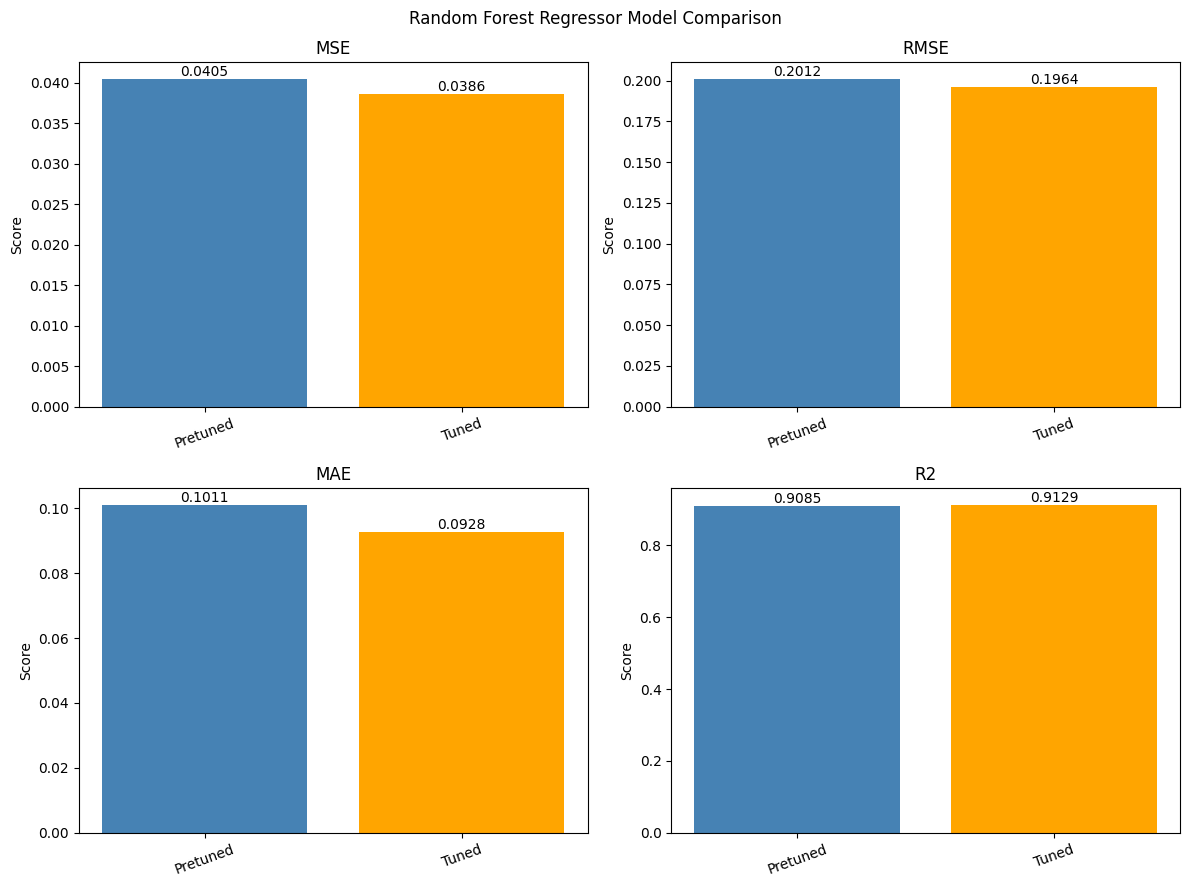

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

metrics = ['MSE', 'RMSE', 'MAE', 'R2']

for ax, metric in zip(axes.flatten(), metrics):

    values = [
        models_compare[model][metric]
        for model in models_compare
    ]

    bars = ax.bar(
        models_compare.keys(),
        values,
        color=['steelblue', 'orange']
    )

    ax.set_title(metric)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=20)

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{value:.4f}',
            ha='center',
            va='bottom'
        )

plt.suptitle('Random Forest Regressor Model Comparison')
plt.tight_layout()
plt.show()

### Feature Importance


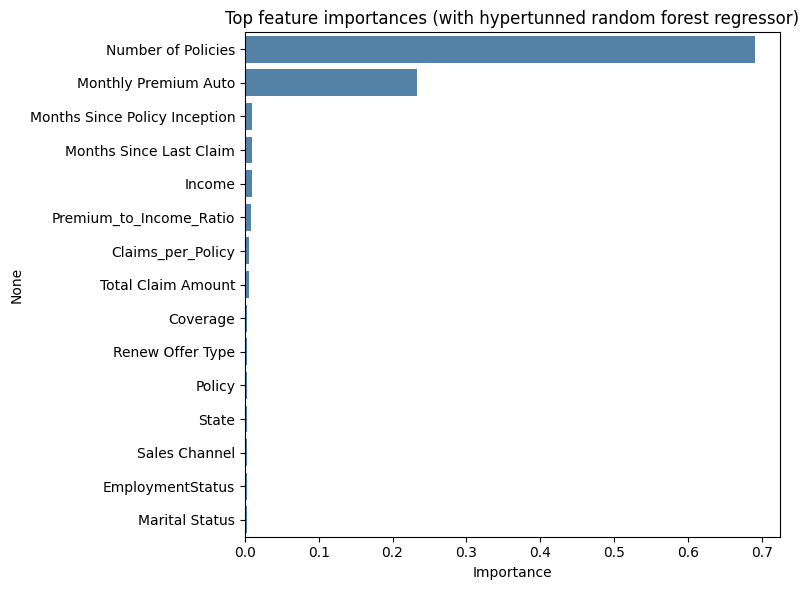

In [39]:
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color='steelblue')
plt.title("Top feature importances (with hypertunned random forest regressor)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

The number of policies and monthly premium have the most influence over the result of CLV.


### Residual Analysis

Check if errors are random or worse for high CLV customers.


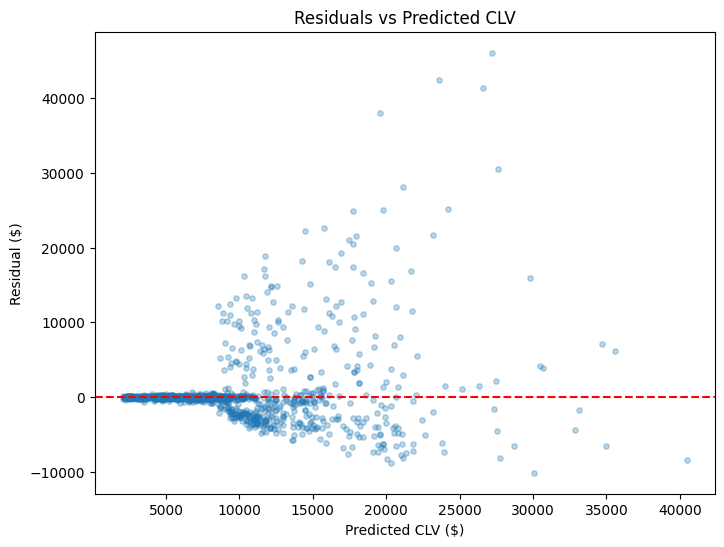

In [40]:
y_test_dollar = np.expm1(y_test)
pred_best_dollar = np.expm1(y_pred)
residuals = y_test_dollar - pred_best_dollar
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(pred_best_dollar, residuals, alpha=0.3, s=15)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Predicted CLV ($)")
ax.set_ylabel("Residual ($)")
ax.set_title("Residuals vs Predicted CLV")

plt.show()

Model predicts low CLV pretty well, but has larger errors on higher CLV.
